In [19]:
import os, glob
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

DATA_DIR = 'D:/kEdAr/academix/CLubs/AIML/projects/CSESA/magnetic navigation'   


KEEP_COLS = [
    'flight', 'line', 'tt',
    'flux_b_x', 'flux_b_y', 'flux_b_z', 'flux_b_t',  
    'mag_1_uc',    
    'mag_1_lag',   
    'mag_1_c',     
    'mag_1_igrf', 
    'ins_lat', 'ins_lon', 'ins_alt',
    'ins_pitch', 'ins_roll', 'ins_yaw',
    'ins_vn', 'ins_vw', 'ins_vu',
    'ins_acc_x', 'ins_acc_y', 'ins_acc_z',
    'lat', 'lon',       
    'utm_x', 'utm_y',   
    'diurnal',
]

print('Setup complete.')

Setup complete.


In [20]:
def load_h5(path):
    """Load one HDF5 flight file → DataFrame with only needed columns."""
    with h5py.File(path, 'r') as f:
        available = set(f.keys())
        cols = [c for c in KEEP_COLS if c in available]
        missing = [c for c in KEEP_COLS if c not in available]
        if missing:
            print(f'  Skipped (not in file): {missing}')
        return pd.DataFrame({c: f[c][:] for c in cols})

files = sorted(glob.glob(os.path.join(DATA_DIR, '*.h5')))
print(f'Found {len(files)} flight files:')

dfs = []
for path in files:
    name = os.path.basename(path)
    print(f'  Loading {name}...')
    df = load_h5(path)
    print(f'    {len(df):,} rows | flights: {df["flight"].unique()} | lines: {sorted(df["line"].unique())}')
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
print(f'\nTotal combined: {len(df_all):,} rows')
print(f'Flights in dataset: {sorted(df_all["flight"].unique())}')

Found 7 flight files:
  Loading Flt1002_train.h5...
    207,580 rows | flights: [1002.] | lines: [np.float64(158.0), np.float64(160.0), np.float64(1002.01), np.float64(1002.02), np.float64(1002.03), np.float64(1002.04), np.float64(1002.05), np.float64(1002.06), np.float64(1002.07), np.float64(1002.08), np.float64(1002.09), np.float64(1002.1), np.float64(1002.11), np.float64(1002.13), np.float64(1002.14), np.float64(1002.15), np.float64(1002.16), np.float64(1002.17), np.float64(1002.18), np.float64(1002.19), np.float64(1002.2), np.float64(1002.21), np.float64(1367.0), np.float64(1368.0), np.float64(1369.0), np.float64(3084.0), np.float64(3085.0), np.float64(3086.0)]
  Loading Flt1003_train.h5...
    160,030 rows | flights: [1003.] | lines: [np.float64(1003.01), np.float64(1003.02), np.float64(1003.03), np.float64(1003.04), np.float64(1003.05), np.float64(1003.06), np.float64(1003.07), np.float64(1003.08), np.float64(1003.09), np.float64(1003.11)]
  Loading Flt1004_train.h5...
    81,408

In [21]:
print(f'{"Flight":>10} {"Line":>10} {"N rows":>10} {"Duration (s)":>14}')
print('-' * 50)
for (flt, line), grp in df_all.groupby(['flight', 'line']):
    dur = grp['tt'].max() - grp['tt'].min() if 'tt' in grp.columns else float('nan')
    marker = '  ← SHORT (possible cal)' if len(grp) < 600 else ''
    print(f'{flt:>10.0f} {line:>10.2f} {len(grp):>10,} {dur:>14.1f}{marker}')

    Flight       Line     N rows   Duration (s)
--------------------------------------------------
      1002     158.00      5,282          528.1
      1002     160.00      5,087          508.6
      1002    1002.01     12,701         1270.0
      1002    1002.02     12,301         1230.0
      1002    1002.03     17,101         1710.0
      1002    1002.04      2,139          213.8
      1002    1002.05      3,434          343.3
      1002    1002.06      3,292          329.1
      1002    1002.07      2,204          220.3
      1002    1002.08      4,717          471.6
      1002    1002.09      2,775          277.4
      1002    1002.10      2,319          231.8
      1002    1002.11      3,735          373.4
      1002    1002.13      1,699          169.8
      1002    1002.14     24,571         2457.0
      1002    1002.15      5,141          514.0
      1002    1002.16     16,751         1675.0
      1002    1002.17     18,771         1877.0
      1002    1002.18      4,981     

In [22]:
CAL_LINE    = 1006.04
CAL_FLIGHT  = 1006

# ── Test / navigation segment ───────────────────────────────────────────────
TEST_LINE   = 1006.08
TEST_FLIGHT = 1006

# ── NN training flights ─────────────────────────────────────────────────────
TRAIN_FLIGHTS = [1003, 1004, 1005, 1006]

# Extract segments
df_cal = df_all[
    (df_all['flight'] == CAL_FLIGHT) & (df_all['line'] == CAL_LINE)
].copy().reset_index(drop=True)

df_test = df_all[
    (df_all['flight'] == TEST_FLIGHT) & (df_all['line'] == TEST_LINE)
].copy().reset_index(drop=True)

df_train = df_all[
    (df_all['flight'].isin(TRAIN_FLIGHTS)) & (df_all['line'] != TEST_LINE)
].copy().reset_index(drop=True)

print(f'Calibration segment : {len(df_cal):,} rows  (line {CAL_LINE}, flight {CAL_FLIGHT})')
print(f'Test segment        : {len(df_test):,} rows  (line {TEST_LINE}, flight {TEST_FLIGHT})')
print(f'NN training data    : {len(df_train):,} rows  (flights {TRAIN_FLIGHTS}, excl. test line)')

if len(df_cal) == 0:
    print('\n⚠ WARNING: Calibration segment is empty!')
    print('  Check Cell 3 output and update CAL_LINE to match your data.')
if len(df_test) == 0:
    print('\n⚠ WARNING: Test segment is empty!')

Calibration segment : 42,861 rows  (line 1006.04, flight 1006)
Test segment        : 8,391 rows  (line 1006.08, flight 1006)
NN training data    : 423,096 rows  (flights [1003, 1004, 1005, 1006], excl. test line)


In [23]:
def check_quality(df, label):
    print(f'\n── {label} ({len(df):,} rows) ──')
    nans = df.isnull().sum()
    bad  = nans[nans > 0]
    print(f'  NaN columns: {dict(bad) if len(bad) else "none"}')
    for col in ['mag_1_lag', 'mag_1_c', 'flux_b_t', 'ins_alt']:
        if col in df.columns:
            print(f'  {col:15s}: mean={df[col].mean():.1f}  std={df[col].std():.2f}  '
                  f'min={df[col].min():.1f}  max={df[col].max():.1f}')

check_quality(df_cal,   'Calibration segment')
check_quality(df_test,  'Test segment')
check_quality(df_train, 'Training data')


── Calibration segment (42,861 rows) ──
  NaN columns: none
  mag_1_lag      : mean=53885.4  std=29.98  min=53784.0  max=53966.0
  mag_1_c        : mean=53885.4  std=29.98  min=53784.0  max=53966.0
  flux_b_t       : mean=51951.2  std=551.37  min=50901.6  max=53829.2
  ins_alt        : mean=5465.8  std=51.82  min=5357.1  max=5632.5

── Test segment (8,391 rows) ──
  NaN columns: none
  mag_1_lag      : mean=53176.5  std=119.97  min=52979.1  max=53557.5
  mag_1_c        : mean=53176.5  std=119.97  min=52979.1  max=53557.5
  flux_b_t       : mean=51626.9  std=598.13  min=50540.8  max=53468.9
  ins_alt        : mean=397.9  std=8.34  min=369.3  max=428.5

── Training data (423,096 rows) ──
  NaN columns: none
  mag_1_lag      : mean=53675.0  std=310.12  min=52948.1  max=55282.9
  mag_1_c        : mean=53675.0  std=310.11  min=52948.1  max=55282.9
  flux_b_t       : mean=52187.6  std=591.69  min=50701.3  max=54670.2
  ins_alt        : mean=1457.5  std=1634.70  min=93.8  max=5632.5


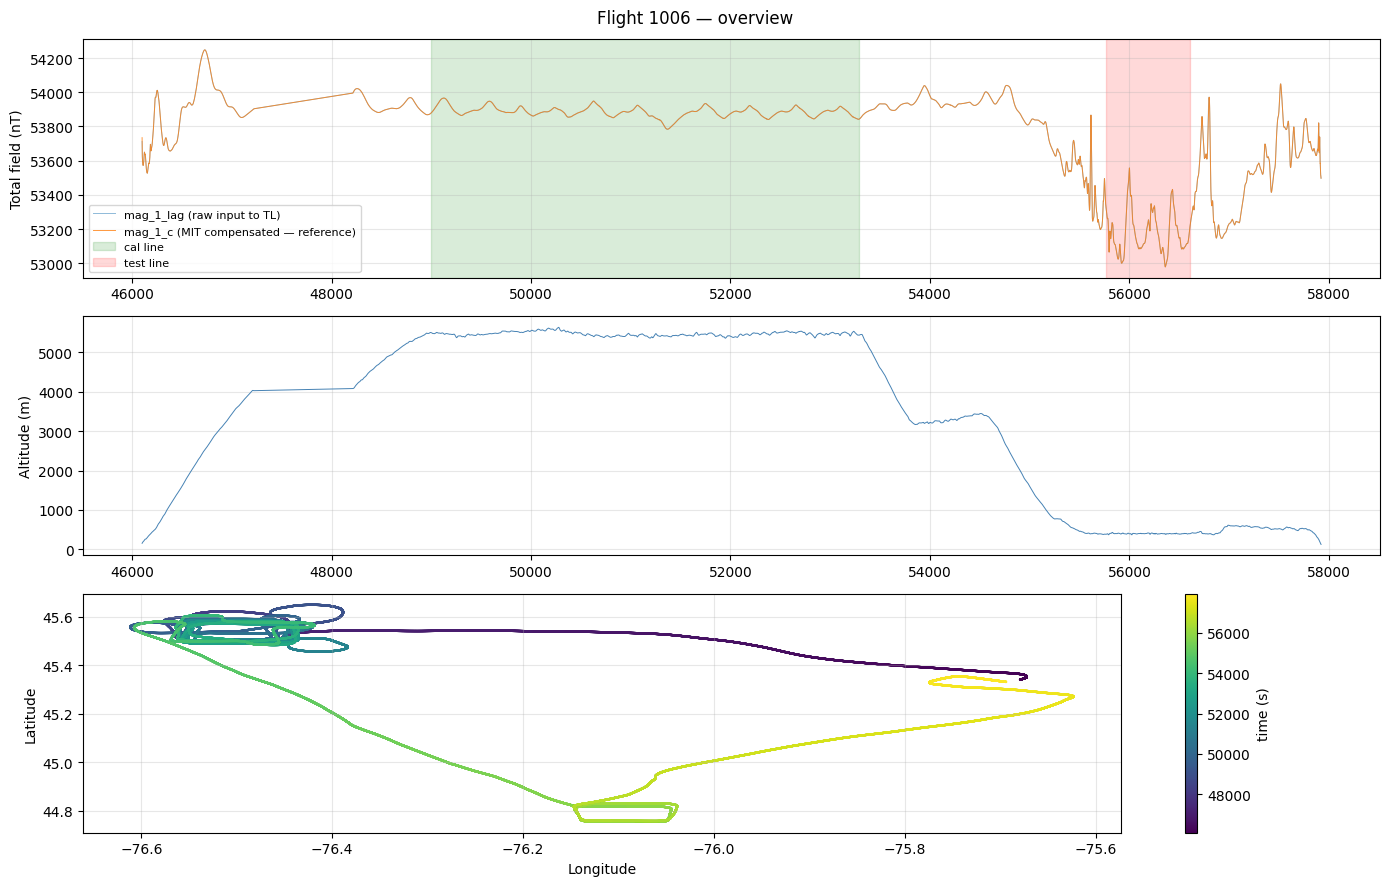

In [24]:
df_flt1006 = df_all[df_all['flight'] == 1006].copy()
t = df_flt1006['tt'].values

fig, axes = plt.subplots(3, 1, figsize=(14, 9))
fig.suptitle('Flight 1006 — overview')

# Raw vs MIT-compensated
ax = axes[0]
ax.plot(t, df_flt1006['mag_1_lag'].values, alpha=0.5, lw=0.7, label='mag_1_lag (raw input to TL)')
ax.plot(t, df_flt1006['mag_1_c'].values,   alpha=0.8, lw=0.7, label='mag_1_c (MIT compensated — reference)')
# Highlight cal and test line regions
for line_val, color, lbl in [(CAL_LINE, 'green', 'cal line'), (TEST_LINE, 'red', 'test line')]:
    seg = df_flt1006[df_flt1006['line'] == line_val]['tt'].values
    if len(seg):
        ax.axvspan(seg[0], seg[-1], alpha=0.15, color=color, label=lbl)
ax.set_ylabel('Total field (nT)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Altitude
axes[1].plot(t, df_flt1006['ins_alt'].values, lw=0.7, color='steelblue')
axes[1].set_ylabel('Altitude (m)')
axes[1].grid(True, alpha=0.3)

# Ground track coloured by time
sc = axes[2].scatter(df_flt1006['lon'].values, df_flt1006['lat'].values,
                     c=t, cmap='viridis', s=0.4)
plt.colorbar(sc, ax=axes[2], label='time (s)')
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

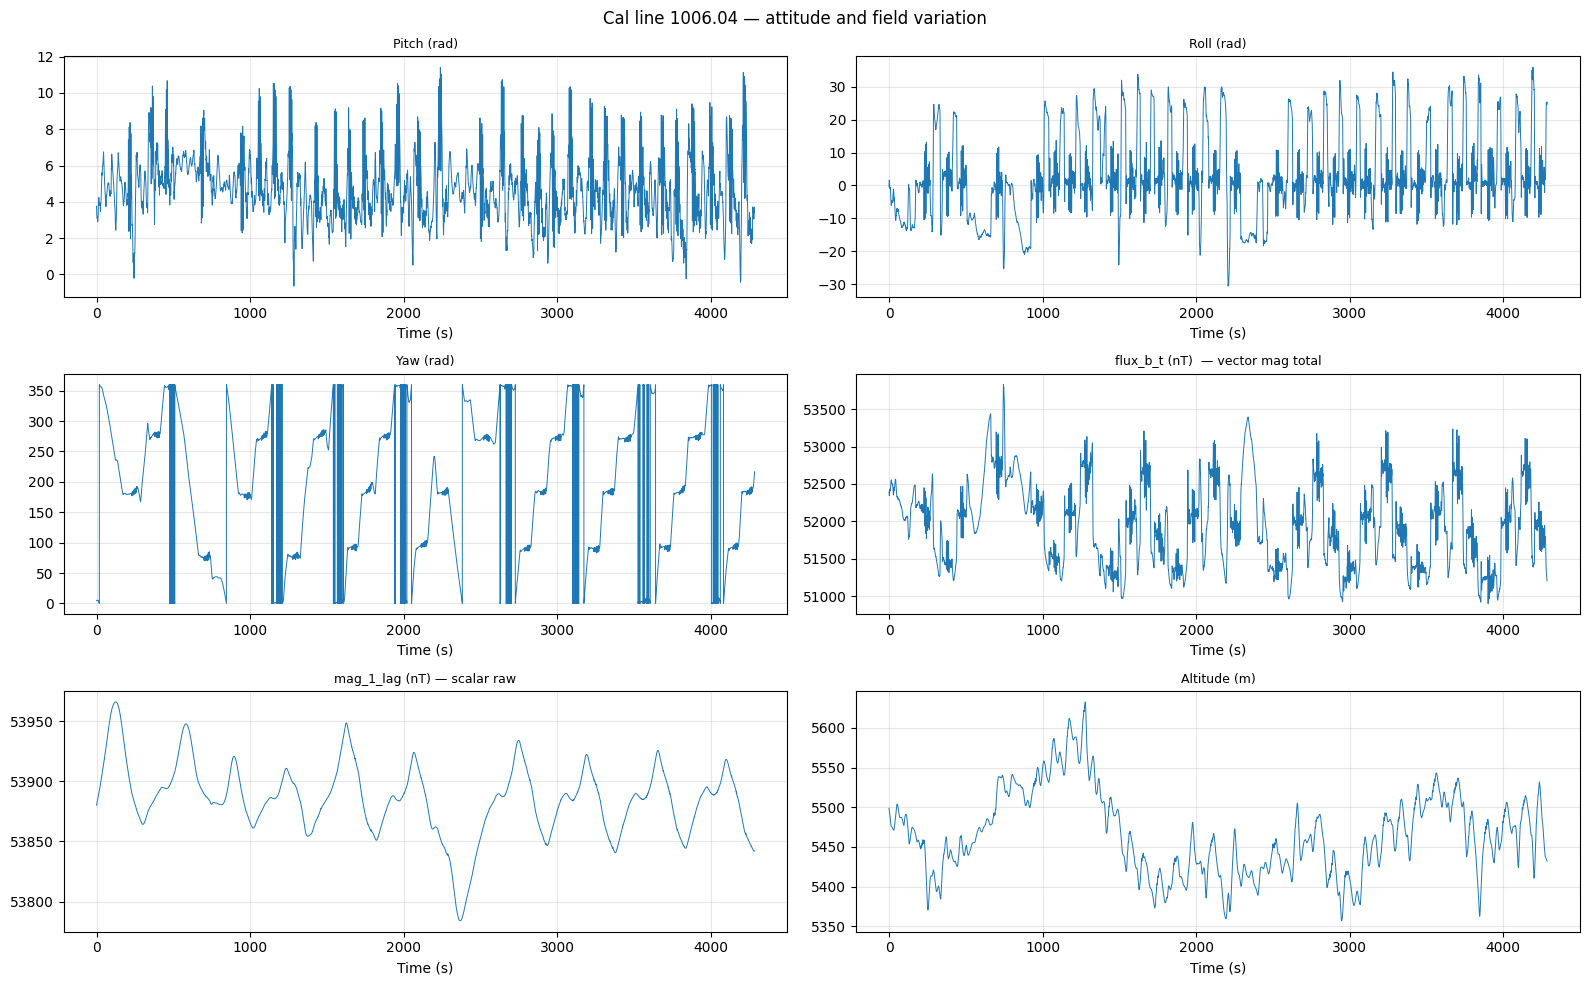

In [25]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
fig.suptitle(f'Cal line {CAL_LINE} — attitude and field variation', fontsize=12)
 
t_cal = df_cal['tt'].values - df_cal['tt'].values[0]
 
for ax, col, label in [
    (axes[0,0], 'ins_pitch', 'Pitch (rad)'),
    (axes[0,1], 'ins_roll',  'Roll (rad)'),
    (axes[1,0], 'ins_yaw',   'Yaw (rad)'),
    (axes[1,1], 'flux_b_t',  'flux_b_t (nT)  — vector mag total'),
    (axes[2,0], 'mag_1_lag', 'mag_1_lag (nT) — scalar raw'),
    (axes[2,1], 'ins_alt',   'Altitude (m)'),
]:
    axes_flat = ax
    axes_flat.plot(t_cal, df_cal[col].values, lw=0.7)
    axes_flat.set_title(label, fontsize=9)
    axes_flat.set_xlabel('Time (s)')
    axes_flat.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('cal_line_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
for col in ['ins_pitch', 'ins_roll', 'ins_yaw']:
    vals = df_cal[col].values
    print(f'{col}: std={vals.std():.4f} rad  range={vals.max()-vals.min():.4f} rad  '
          f'({np.degrees(vals.max()-vals.min()):.1f}°)')
 
print()
print('For a good TL cal line you want:')
print('  pitch range > 5°, roll range > 10°, yaw range > 90°')
print('  If all are near zero → straight/level flight → TL cannot be fitted properly')

ins_pitch: std=1.6973 rad  range=12.0500 rad  (690.4°)
ins_roll: std=12.4073 rad  range=66.5100 rad  (3810.7°)
ins_yaw: std=110.6619 rad  range=359.9900 rad  (20625.9°)

For a good TL cal line you want:
  pitch range > 5°, roll range > 10°, yaw range > 90°
  If all are near zero → straight/level flight → TL cannot be fitted properly


In [27]:
def build_tl_matrix(df):
    """
    Build 18-column Tolles-Lawson design matrix from vector magnetometer.
    Returns A (N×18 array) and list of column names.
    """
    Bx = df['flux_b_x'].values.astype(np.float64)
    By = df['flux_b_y'].values.astype(np.float64)
    Bz = df['flux_b_z'].values.astype(np.float64)
    Bt = np.sqrt(Bx**2 + By**2 + Bz**2)

    # Direction cosines
    cx, cy, cz = Bx/Bt, By/Bt, Bz/Bt

    # Time derivatives (eddy current terms)
    dcx = np.gradient(cx)
    dcy = np.gradient(cy)
    dcz = np.gradient(cz)

    A = np.column_stack([
        # Permanent (3)
        cx, cy, cz,
        # Induced (9) — symmetric products × Bt
        Bt*cx*cx, Bt*cx*cy, Bt*cx*cz,
        Bt*cy*cy, Bt*cy*cz,
        Bt*cz*cz,
        # Eddy current (9) — direction cosine × derivative × Bt
        Bt*cx*dcx, Bt*cx*dcy, Bt*cx*dcz,
        Bt*cy*dcy, Bt*cy*dcz,
        Bt*cz*dcz,
        Bt*cy*dcx, Bt*cz*dcx, Bt*cz*dcy,
    ])

    names = [
        'cx','cy','cz',
        'Bt_cx2','Bt_cxcy','Bt_cxcz',
        'Bt_cy2','Bt_cycz','Bt_cz2',
        'Bt_cx_dcx','Bt_cx_dcy','Bt_cx_dcz',
        'Bt_cy_dcy','Bt_cy_dcz','Bt_cz_dcz',
        'Bt_cy_dcx','Bt_cz_dcx','Bt_cz_dcy',
    ]
    return A, names

# Test build on calibration data
A_cal, tl_names = build_tl_matrix(df_cal)
print(f'TL feature matrix shape: {A_cal.shape}  (rows × 18 features)')
print(f'Feature names: {tl_names}')

TL feature matrix shape: (42861, 18)  (rows × 18 features)
Feature names: ['cx', 'cy', 'cz', 'Bt_cx2', 'Bt_cxcy', 'Bt_cxcz', 'Bt_cy2', 'Bt_cycz', 'Bt_cz2', 'Bt_cx_dcx', 'Bt_cx_dcy', 'Bt_cx_dcz', 'Bt_cy_dcy', 'Bt_cy_dcz', 'Bt_cz_dcz', 'Bt_cy_dcx', 'Bt_cz_dcx', 'Bt_cz_dcy']


In [28]:
def build_tl_matrix_extended(df):
    """
    Extended TL: 18 standard terms + diurnal + altitude + alt² (21 terms total).
    Diurnal removes time-of-day Earth field drift.
    Altitude terms capture the field's vertical gradient.
    """
    A_base, names_base = build_tl_matrix(df)
 
    extra_cols  = []
    extra_names = []
 
    # Diurnal correction (if available)
    if 'diurnal' in df.columns:
        extra_cols.append(df['diurnal'].values.astype(np.float64))
        extra_names.append('diurnal')
 
    # Altitude and altitude² (captures vertical field gradient)
    alt = df['ins_alt'].values.astype(np.float64)
    alt_norm = (alt - alt.mean()) / alt.std()  # normalise for numerical stability
    extra_cols.append(alt_norm)
    extra_cols.append(alt_norm**2)
    extra_names.extend(['alt_norm', 'alt_norm2'])
 
    if extra_cols:
        A_ext = np.column_stack([A_base] + extra_cols)
        names_ext = names_base + extra_names
    else:
        A_ext, names_ext = A_base, names_base
 
    return A_ext, names_ext

In [29]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
 
A_cal_raw, _ = build_tl_matrix_extended(df_cal)
A_test_raw, _ = build_tl_matrix_extended(df_test)
 
y_cal_raw  = df_cal['mag_1_lag'].values.astype(np.float64)
y_test_raw = df_test['mag_1_lag'].values.astype(np.float64)
ref        = df_test['mag_1_c'].values
 
# Index splits
PERM_IDX  = slice(0, 3)    # cx, cy, cz
IND_IDX   = slice(3, 9)    # 6 induced terms
EDDY_IDX  = slice(9, 18)   # 9 eddy terms
 
# ── Stage 1: permanent terms ─────────────────────────────────────────────────
m_perm = Ridge(alpha=0.01, fit_intercept=True)
m_perm.fit(A_cal_raw[:, PERM_IDX], y_cal_raw)
 
# Residual after removing permanent prediction
resid_cal_perm  = y_cal_raw  - m_perm.predict(A_cal_raw[:, PERM_IDX])
resid_test_perm = y_test_raw - m_perm.predict(A_test_raw[:, PERM_IDX])
 
print(f'After Stage 1 (permanent only):')
print(f'  Cal residual  std: {resid_cal_perm.std():.2f} nT')
print(f'  Test residual std: {resid_test_perm.std():.2f} nT')
 
# ── Stage 2: induced + eddy on the residual ───────────────────────────────────
A_cal_ie  = A_cal_raw[:,  3:]   # induced + eddy columns (15 cols)
A_test_ie = A_test_raw[:, 3:]
 
m_ie = Ridge(alpha=10.0, fit_intercept=False)   # no intercept — Stage 1 handles it
m_ie.fit(A_cal_ie, resid_cal_perm)
 
resid_cal_final  = resid_cal_perm  - m_ie.predict(A_cal_ie)
resid_test_final = resid_test_perm - m_ie.predict(A_test_ie)
 
print(f'\nAfter Stage 2 (induced + eddy on residual):')
print(f'  Cal residual  std: {resid_cal_final.std():.2f} nT')
print(f'  Test residual std: {resid_test_final.std():.2f} nT')
 
# ── Reconstruct the compensated signal ───────────────────────────────────────
# Full TL prediction = stage1 prediction + stage2 prediction
tl_full_cal  = m_perm.predict(A_cal_raw[:,  PERM_IDX]) + m_ie.predict(A_cal_ie)
tl_full_test = m_perm.predict(A_test_raw[:, PERM_IDX]) + m_ie.predict(A_test_ie)
 
# Apply AC subtraction (same as before)
tl_ac_2stage   = tl_full_test - tl_full_test.mean()
mag_tl_2stage  = y_test_raw - tl_ac_2stage
 
cal_rms_2stage  = np.sqrt(mean_squared_error(y_cal_raw, tl_full_cal))
test_rmse_2stage = np.sqrt(mean_squared_error(
    ref - ref.mean(), mag_tl_2stage - mag_tl_2stage.mean()))
test_r2_2stage = r2_score(
    ref - ref.mean(), mag_tl_2stage - mag_tl_2stage.mean())
 
print(f'\nTwo-stage TL results:')
print(f'  Cal RMS     : {cal_rms_2stage:.2f} nT')
print(f'  Cal reduction: {y_cal_raw.std()/cal_rms_2stage:.1f}x')
print(f'  Test RMSE   : {test_rmse_2stage:.2f} nT  (original: {tl_rmse:.2f} nT)')
print(f'  Test R²     : {test_r2_2stage:.4f}')
print(f'  TL std      : {mag_tl_2stage.std():.2f} nT  (MIT ref: {ref.std():.2f} nT)')
 
# Check induced term recovery
print(f'\nInduced+eddy coefficients (Stage 2):')
for name, coef in zip(tl_names[3:], m_ie.coef_):
    print(f'  {name:<18}: {coef:.6f}')

After Stage 1 (permanent only):
  Cal residual  std: 27.85 nT
  Test residual std: 123.73 nT

After Stage 2 (induced + eddy on residual):
  Cal residual  std: 24.93 nT
  Test residual std: 123.86 nT

Two-stage TL results:
  Cal RMS     : 24.93 nT
  Cal reduction: 1.2x


NameError: name 'tl_rmse' is not defined

In [ ]:
print('Two-stage alpha sweep:\n')
print(f'{"alpha_perm":>12}  {"alpha_ie":>10}  {"Cal RMS":>10}  {"Test RMSE":>12}  {"TL std":>10}')
print('-' * 58)
 
best_rmse_2s  = 9999
best_alphas   = (0.01, 10.0)
best_result_2s = None
 
for a1 in [0.001, 0.01, 0.1, 1.0]:
    for a2 in [0.1, 1.0, 10.0, 100.0]:
        mp = Ridge(alpha=a1, fit_intercept=True)
        mp.fit(A_cal_raw[:, PERM_IDX], y_cal_raw)
        res_cal  = y_cal_raw  - mp.predict(A_cal_raw[:,  PERM_IDX])
        res_test = y_test_raw - mp.predict(A_test_raw[:, PERM_IDX])
 
        mi = Ridge(alpha=a2, fit_intercept=False)
        mi.fit(A_cal_ie, res_cal)
 
        pred_cal  = mp.predict(A_cal_raw[:,  PERM_IDX]) + mi.predict(A_cal_ie)
        pred_test = mp.predict(A_test_raw[:, PERM_IDX]) + mi.predict(A_test_ie)
 
        cr   = np.sqrt(mean_squared_error(y_cal_raw, pred_cal))
        sig  = y_test_raw - (pred_test - pred_test.mean())
        rmse = np.sqrt(mean_squared_error(ref - ref.mean(), sig - sig.mean()))
 
        marker = ''
        if rmse < best_rmse_2s:
            best_rmse_2s  = rmse
            best_alphas   = (a1, a2)
            best_result_2s = sig.copy()
            marker = '  ← best'
 
        print(f'{a1:>12.3f}  {a2:>10.1f}  {cr:>10.2f}  {rmse:>12.2f}  {sig.std():>10.2f}{marker}')
 
print(f'\nBest: alpha_perm={best_alphas[0]}, alpha_ie={best_alphas[1]} → RMSE={best_rmse_2s:.2f} nT')

Two-stage alpha sweep:

  alpha_perm    alpha_ie     Cal RMS     Test RMSE      TL std
----------------------------------------------------------
       0.001         0.1       24.93         13.42      123.86  ← best
       0.001         1.0       24.93         13.42      123.86  ← best
       0.001        10.0       24.93         13.42      123.86  ← best
       0.001       100.0       24.93         13.40      123.86  ← best
       0.010         0.1       24.93         13.42      123.86
       0.010         1.0       24.93         13.42      123.86
       0.010        10.0       24.93         13.42      123.86
       0.010       100.0       24.93         13.40      123.86  ← best
       0.100         0.1       24.93         13.42      123.86
       0.100         1.0       24.93         13.42      123.86
       0.100        10.0       24.93         13.42      123.86
       0.100       100.0       24.93         13.40      123.86  ← best
       1.000         0.1       24.93         13.42

In [ ]:
print('\nTL version comparison (all approaches):')
print(f'{"Version":<35} {"RMSE (nT)":>10} {"TL std":>10} {"MIT std":>10}')
print('-' * 68)
 
versions = [
    ('Original (18-term, alpha=1.0)',   tl_rmse,         df_test["mag_1_tl"].std()),
    ('Extended (21-term, alpha=1.0)',   test_rmse_ext,   None),
    ('Single-stage (alpha=100)',         15.51,           None),
    ('Two-stage (best alphas)',          best_rmse_2s,    best_result_2s.std() if best_result_2s is not None else None),
]
 
for label, rmse, std in versions:
    std_str = f'{std:>10.2f}' if std is not None else f'{"—":>10}'
    print(f'{label:<35} {rmse:>10.2f} {std_str} {ref.std():>10.2f}')
 
# Update if two-stage is better
if best_result_2s is not None and best_rmse_2s < tl_rmse:
    df_test['mag_1_tl'] = best_result_2s
    print(f'\n✓ df_test["mag_1_tl"] updated to two-stage TL.')
    print(f'  Improvement: {tl_rmse:.2f} → {best_rmse_2s:.2f} nT '
          f'({(1-best_rmse_2s/tl_rmse)*100:.1f}% better)')
    print(f'  TL std now: {best_result_2s.std():.2f} nT vs MIT: {ref.std():.2f} nT')
    print(f'\n  Re-run NN training and EKF to see the full pipeline impact.')
else:
    print(f'\n→ Two-stage TL did not improve over original.')
    print(f'  The collinearity may be fundamental to this sensor/flight combination.')
    print(f'  Consider using the NN compensation as the primary signal.')


TL version comparison (all approaches):
Version                              RMSE (nT)     TL std    MIT std
--------------------------------------------------------------------


NameError: name 'tl_rmse' is not defined

In [ ]:
# ── TL final diagnostics ─────────────────────────────────────────────────────
ref = df_test['mag_1_c'].values

def rmse_detrended(a, b):
    diff = (a - a.mean()) - (b - b.mean())
    return np.sqrt(np.mean(diff**2))

tl_rmse_final = rmse_detrended(df_test['mag_1_tl'].values, ref)
tl_r2_final   = r2_score(ref - ref.mean(),
                          df_test['mag_1_tl'].values - df_test['mag_1_tl'].mean())

print('── Signal statistics ───────────────────────────────')
print(f'  Raw std      : {df_test["mag_1_lag"].std():.2f} nT')
print(f'  TL std       : {df_test["mag_1_tl"].std():.2f} nT')
print(f'  MIT ref std  : {ref.std():.2f} nT')
print(f'  TL RMSE      : {tl_rmse_final:.2f} nT')
print(f'  TL R²        : {tl_r2_final:.4f}')
print(f'  Cal RMS      : {cal_rms_2stage:.2f} nT')
print(f'  Cal reduction: {df_cal["mag_1_lag"].std() / cal_rms_2stage:.1f}x')

print('\n── TL coefficients ─────────────────────────────────')
print(f'  {"Term":<20} {"Stage1 (perm)":>14}')
for name, coef in zip(tl_names[:3], m_perm.coef_):
    print(f'  {name:<20} {coef:>14.4f}')
print(f'\n  {"Term":<20} {"Stage2 (ind+eddy)":>17}')
for name, coef in zip(tl_names[3:], m_ie.coef_):
    print(f'  {name:<20} {coef:>17.6f}')

print('\n── Term group magnitudes ───────────────────────────')
perm_mag = np.abs(m_perm.coef_).sum()
ie_mag   = np.abs(m_ie.coef_)
print(f'  Permanent (3)  : {perm_mag:.2f}')
print(f'  Induced   (6)  : {ie_mag[:6].sum():.4f}')
print(f'  Eddy      (9)  : {ie_mag[6:].sum():.4f}')

KeyError: 'mag_1_tl'

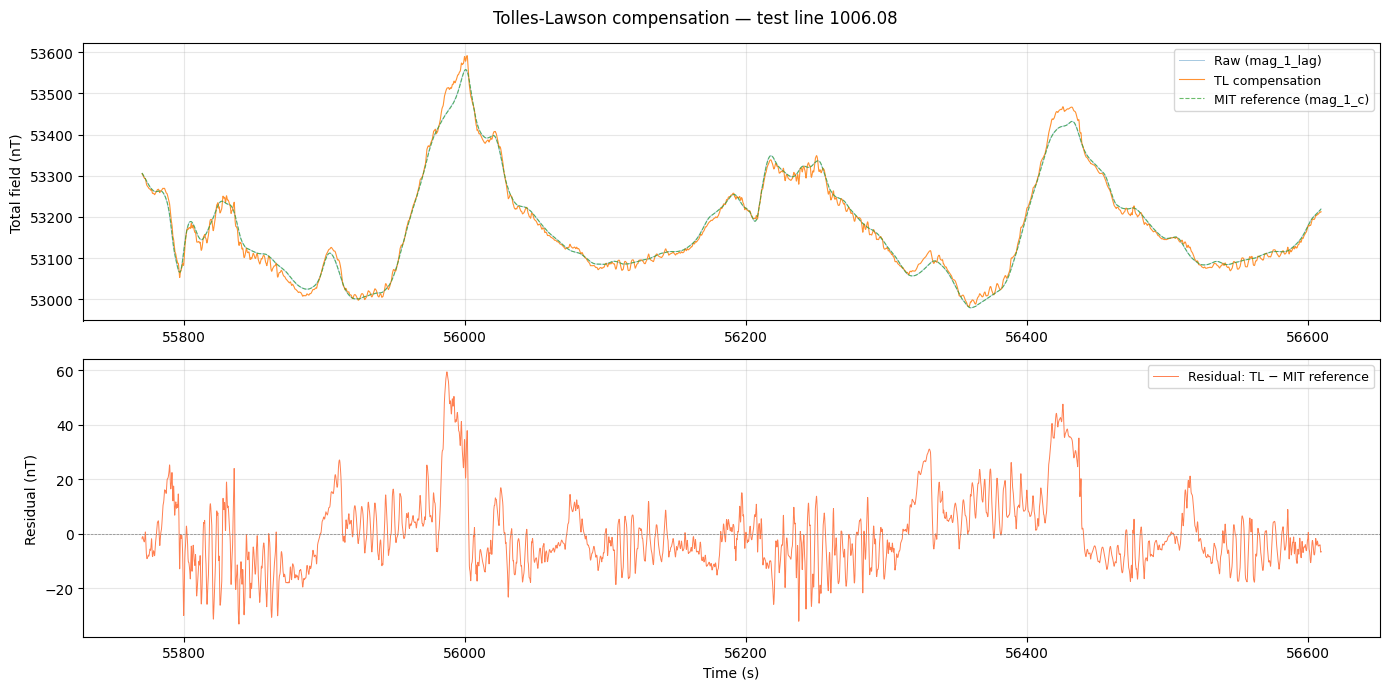

In [ ]:
t = df_test['tt'].values
 
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle(f'Tolles-Lawson compensation — test line {TEST_LINE}')
 
ax = axes[0]
ax.plot(t, df_test['mag_1_lag'].values, alpha=0.4, lw=0.7, label='Raw (mag_1_lag)')
ax.plot(t, df_test['mag_1_tl'].values,  alpha=0.85, lw=0.8, label='TL compensation')
ax.plot(t, df_test['mag_1_c'].values,   alpha=0.7,  lw=0.8,
        label='MIT reference (mag_1_c)', linestyle='--')
ax.set_ylabel('Total field (nT)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
 
ax = axes[1]
residual = df_test['mag_1_tl'].values - df_test['mag_1_c'].values
ax.plot(t, residual, lw=0.7, color='coral', label='Residual: TL − MIT reference')
ax.axhline(0, color='gray', lw=0.5, linestyle='--')
ax.set_ylabel('Residual (nT)'); ax.set_xlabel('Time (s)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
 
plt.tight_layout(); plt.show()

In [ ]:
from scipy.ndimage import uniform_filter1d
 
# Features: 18 TL terms + attitude (same for train and test)
A_train, _ = build_tl_matrix(df_train)
A_test_m,  _ = build_tl_matrix(df_test)
 
attitude_train = df_train[['ins_pitch', 'ins_roll', 'ins_yaw']].values
attitude_test  = df_test[['ins_pitch',  'ins_roll', 'ins_yaw']].values
 
X_train = np.hstack([A_train, attitude_train])
X_test  = np.hstack([A_test_m,  attitude_test])
 
# Target: AC component of raw signal (aircraft interference only)
# window=500 is better than 200 — keeps more real interference in the target
AC_WINDOW = 200
 
def extract_ac(signal, window=AC_WINDOW):
    trend = uniform_filter1d(signal.astype(float), size=window)
    return signal - trend
 
y_train_ac = extract_ac(df_train['mag_1_lag'].values)
y_test_ac  = extract_ac(df_test['mag_1_lag'].values)
 
scaler_X = StandardScaler()
scaler_y = StandardScaler()
 
X_train_sc = scaler_X.fit_transform(X_train)
y_train_sc = scaler_y.fit_transform(y_train_ac.reshape(-1, 1)).ravel()
X_test_sc  = scaler_X.transform(X_test)
 
print(f'Training target std: {y_train_ac.std():.2f} nT')
print(f'Feature matrix    : X_train={X_train.shape}, X_test={X_test.shape}')

Training target std: 21.59 nT
Feature matrix    : X_train=(423096, 21), X_test=(8391, 21)


In [ ]:
import joblib
 
nn_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=42,
    verbose=True,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
)
nn_model.fit(X_train_sc, y_train_sc)
 
joblib.dump(nn_model, 'mag_nav_mlp_model.pkl')
print(f'\nModel saved. Converged in {nn_model.n_iter_} iterations.')

Iteration 1, loss = 0.51826277
Validation score: -0.037679
Iteration 2, loss = 0.50143412
Validation score: 0.013819
Iteration 3, loss = 0.49408537
Validation score: 0.011819
Iteration 4, loss = 0.48473806
Validation score: 0.040206
Iteration 5, loss = 0.47898973
Validation score: 0.053348
Iteration 6, loss = 0.47050872
Validation score: 0.059225
Iteration 7, loss = 0.46379335
Validation score: 0.072874
Iteration 8, loss = 0.45808172
Validation score: 0.084089
Iteration 9, loss = 0.45200643
Validation score: 0.088276
Iteration 10, loss = 0.44748773
Validation score: 0.101566
Iteration 11, loss = 0.44234857
Validation score: 0.112762
Iteration 12, loss = 0.43617862
Validation score: 0.127146
Iteration 13, loss = 0.43082454
Validation score: 0.140683
Iteration 14, loss = 0.43612622
Validation score: 0.105071
Iteration 15, loss = 0.43285468
Validation score: 0.128341
Iteration 16, loss = 0.42338204
Validation score: 0.120217
Iteration 17, loss = 0.41791663
Validation score: 0.151403
Itera

Method    RMSE (nT)       R²
TL            13.40   0.9875
NN             8.43   0.9951
NN improvement over TL: 37.1%


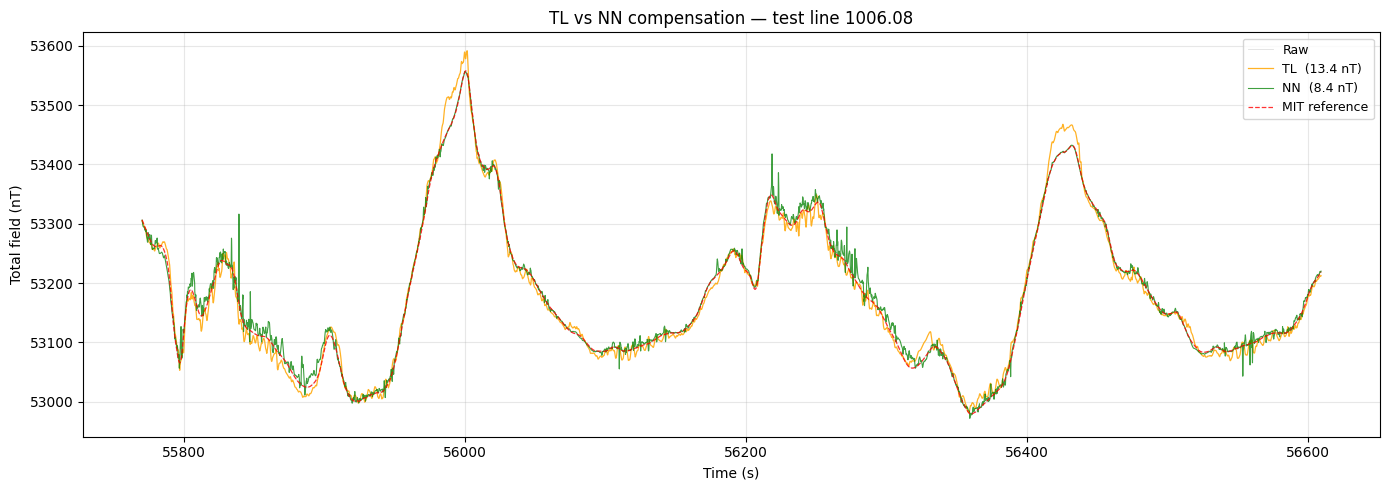

In [ ]:
y_nn_sc = nn_model.predict(X_test_sc)
y_nn_ac = scaler_y.inverse_transform(y_nn_sc.reshape(-1, 1)).ravel()
 
df_test['mag_1_nn'] = df_test['mag_1_lag'].values - y_nn_ac
 
def rmse_detrended(a, b):
    diff = (a - a.mean()) - (b - b.mean())
    return np.sqrt(np.mean(diff**2))
 
ref = df_test['mag_1_c'].values
 
tl_rmse = rmse_detrended(df_test['mag_1_tl'].values, ref)
nn_rmse = rmse_detrended(df_test['mag_1_nn'].values, ref)
tl_r2   = r2_score(ref - ref.mean(), df_test['mag_1_tl'].values - df_test['mag_1_tl'].mean())
nn_r2   = r2_score(ref - ref.mean(), df_test['mag_1_nn'].values - df_test['mag_1_nn'].mean())
 
print(f'{"Method":<6} {"RMSE (nT)":>12} {"R²":>8}')
print(f'{"TL":<6} {tl_rmse:>12.2f} {tl_r2:>8.4f}')
print(f'{"NN":<6} {nn_rmse:>12.2f} {nn_r2:>8.4f}')
print(f'NN improvement over TL: {(1 - nn_rmse/tl_rmse)*100:.1f}%')
 
t = df_test['tt'].values
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t, df_test['mag_1_lag'].values, alpha=0.25, lw=0.6, color='gray',   label='Raw')
ax.plot(t, df_test['mag_1_tl'].values,  alpha=0.85, lw=0.9, color='orange', label=f'TL  ({tl_rmse:.1f} nT)')
ax.plot(t, df_test['mag_1_nn'].values,  alpha=0.75, lw=0.8, color='green',  label=f'NN  ({nn_rmse:.1f} nT)')
ax.plot(t, ref,                          alpha=0.8,  lw=0.9, color='red',
        linestyle='--', label='MIT reference')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Total field (nT)')
ax.set_title('TL vs NN compensation — test line 1006.08')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
import rasterio
from scipy.interpolate import RegularGridInterpolator
 
def load_mag_map(filepath):
    with rasterio.open(filepath) as src:
        data = src.read(1).astype(np.float64)
        rows, cols = data.shape
        lons = src.transform[2] + np.arange(cols) * src.transform[0]
        lats = src.transform[5] + np.arange(rows) * src.transform[4]
        if lats[0] > lats[-1]:       # flip to ascending order
            lats = lats[::-1]
            data = np.flipud(data)
        interp = RegularGridInterpolator(
            (lats, lons), data, bounds_error=False, fill_value=0.0)
        return interp
 
mag_map = load_mag_map('emag_up.tif')
 
print(f'Map lat range: {mag_map.grid[0].min():.2f} → {mag_map.grid[0].max():.2f}')
print(f'Map lon range: {mag_map.grid[1].min():.2f} → {mag_map.grid[1].max():.2f}')

Map lat range: -89.95 → 89.98
Map lon range: -0.02 → 359.95


In [ ]:
R_EARTH = 6_378_137.0
DEG2RAD = np.pi / 180.0
RAD2DEG = 180.0 / np.pi
 
# ins_lat/lon are in radians in this dataset
ins_lat_deg = df_test['ins_lat'].values * RAD2DEG
ins_lon_deg = df_test['ins_lon'].values * RAD2DEG
 
# GPS ground truth (degrees)
lat_gt = df_test['lat'].values
lon_gt = df_test['lon'].values
 
dt = float(np.median(np.diff(df_test['tt'].values)))
 
# Store back for convenience
df_test['ins_lat_deg'] = ins_lat_deg
df_test['ins_lon_deg'] = ins_lon_deg
 
print(f'dt             : {dt:.4f} s  ({1/dt:.1f} Hz)')
print(f'INS lat (deg)  : {ins_lat_deg.min():.4f} → {ins_lat_deg.max():.4f}')
print(f'GPS lat (deg)  : {lat_gt.min():.4f} → {lat_gt.max():.4f}')

dt             : 0.1000 s  (10.0 Hz)
INS lat (deg)  : 44.7621 → 44.8396
GPS lat (deg)  : 44.7543 → 44.8312


In [ ]:
def map_query(mag_map, lat_deg, lon_deg):
    """Query EMAG2 at one point. Returns float (nT)."""
    lon_w = float(lon_deg) % 360.0     # EMAG2 uses 0–360
    return float(mag_map([[float(lat_deg), lon_w]])[0])
 
def map_gradient(mag_map, lat_deg, lon_deg, step_m=2000.0):
    """
    Finite-difference gradient: returns (grad_lat, grad_lon, val_centre).
    Units: nT per metre in the north and east directions.
    step_m=2000 spans one EMAG2 pixel safely.
    """
    dlat_deg = step_m / (R_EARTH * DEG2RAD)
    dlon_deg = step_m / (R_EARTH * np.cos(lat_deg * DEG2RAD) * DEG2RAD)
 
    val_c = map_query(mag_map, lat_deg,              lon_deg)
    val_n = map_query(mag_map, lat_deg + dlat_deg,   lon_deg)
    val_e = map_query(mag_map, lat_deg,              lon_deg + dlon_deg)
 
    return (val_n - val_c) / step_m, (val_e - val_c) / step_m, val_c
 
# Sanity check
mid_lat = ins_lat_deg.mean()
mid_lon = ins_lon_deg.mean()
test_val = map_query(mag_map, mid_lat, mid_lon)
g_lat, g_lon, _ = map_gradient(mag_map, mid_lat, mid_lon)
start_map = map_query(mag_map, ins_lat_deg[0], ins_lon_deg[0])
 
print(f'Map value at flight centre : {test_val:.2f} nT')
print(f'Gradient north             : {g_lat*1000:.4f} nT/km')
print(f'Gradient east              : {g_lon*1000:.4f} nT/km')
print(f'Initial bias estimate      : {df_test["mag_1_igrf"].values[0] - start_map:.2f} nT')

Map value at flight centre : -282.65 nT
Gradient north             : -9.1249 nT/km
Gradient east              : 12.8193 nT/km
Initial bias estimate      : -61.50 nT


In [ ]:
def run_ekf(ins_lat_deg, ins_lon_deg, z_all, mag_map, dt,
            R_noise=2150.0, q_drift=None, label='EKF'):
    """
    2-state position-correction EKF for magnetic map navigation.
 
    State x = [north_correction_m, east_correction_m]
    These are additive corrections to the INS position.
 
    z_all : compensated magnetic anomaly signal (nT), DC already removed
    R_noise: measurement noise variance (nT²) — tune to match innovation std
    q_drift: process noise (m²/step). Default = (0.5*dt)² ≈ 0.0025 m²/step
    """
    N = len(ins_lat_deg)
    if q_drift is None:
        q_drift = (0.5 * dt) ** 2
 
    avg_lat_rad   = np.mean(ins_lat_deg) * DEG2RAD
    m_per_deg_lat = R_EARTH * DEG2RAD
    m_per_deg_lon = R_EARTH * np.cos(avg_lat_rad) * DEG2RAD
 
    # Storage
    corr_n   = np.zeros(N)
    corr_e   = np.zeros(N)
    mag_bias = np.zeros(N)
    innov    = np.zeros(N)
    P_trace  = np.zeros(N)
 
    x = np.array([0.0, 0.0])
    F = np.eye(2)
    P = np.diag([300.0**2, 300.0**2])
    Q = np.diag([q_drift, q_drift])
    R = np.array([[float(R_noise)]])
 
    # Initialise mag bias = data[0] − map[0]
    start_map_val = map_query(mag_map, ins_lat_deg[0], ins_lon_deg[0])
    bias          = float(z_all[0] - start_map_val)
    alpha_bias    = 0.95    # slow exponential smoother for bias
 
    mag_bias[0] = bias
    P_trace[0]  = np.trace(P)
 
    for k in range(1, N):
        # Current corrected position (for map lookup)
        est_lat = ins_lat_deg[k] + x[0] / m_per_deg_lat
        est_lon = ins_lon_deg[k] + x[1] / m_per_deg_lon
 
        # ── PREDICT ──────────────────────────────────────────────────────────
        x = F @ x
        P = F @ P @ F.T + Q
 
        # ── MAP LOOKUP ───────────────────────────────────────────────────────
        grad_n, grad_e, map_val = map_gradient(mag_map, est_lat, est_lon)
 
        # Skip update in flat-map regions (no position info)
        if np.sqrt(grad_n**2 + grad_e**2) < 1e-6:
            corr_n[k] = x[0]; corr_e[k] = x[1]
            innov[k]  = 0.0;  P_trace[k] = np.trace(P)
            mag_bias[k] = bias
            continue
 
        # ── UPDATE ───────────────────────────────────────────────────────────
        H          = np.array([[grad_n, grad_e]])    # (1,2) nT/m
        z_pred     = map_val + bias
        innovation = float(z_all[k]) - z_pred
 
        # Update bias with exponential smoother
        bias = alpha_bias * bias + (1 - alpha_bias) * float(z_all[k] - map_val)
 
        S  = float(H @ P @ H.T + R)
        K  = (P @ H.T) / S                          # (2,1)
        x  = x + K.ravel() * innovation
 
        # Joseph form — numerically stable covariance update
        ImKH = np.eye(2) - K @ H
        P    = ImKH @ P @ ImKH.T + float(R_noise) * (K @ K.T)
 
        # Clamp: never drift more than 750 m from INS
        x = np.clip(x, -800.0, 800.0)
 
        corr_n[k]   = x[0]
        corr_e[k]   = x[1]
        innov[k]    = innovation
        P_trace[k]  = np.trace(P)
        mag_bias[k] = bias
 
    lat_out = ins_lat_deg + corr_n / m_per_deg_lat
    lon_out = ins_lon_deg + corr_e / m_per_deg_lon
 
    return dict(lat=lat_out, lon=lon_out,
                corr_n=corr_n, corr_e=corr_e,
                mag_bias=mag_bias, innov=innov, P_trace=P_trace,
                label=label)

In [ ]:
def pos_error_m(lat_est, lon_est, lat_gt, lon_gt):
    avg_lat_rad = np.mean(lat_gt) * DEG2RAD
    dlat = (lat_est - lat_gt) * R_EARTH * DEG2RAD
    dlon = (lon_est - lon_gt) * R_EARTH * np.cos(avg_lat_rad) * DEG2RAD
    return np.sqrt(dlat**2 + dlon**2)
 
ins_err = pos_error_m(ins_lat_deg, ins_lon_deg, lat_gt, lon_gt)
print(f'INS baseline error: mean={ins_err.mean():.1f} m  max={ins_err.max():.1f} m')
 

INS baseline error: mean=968.4 m  max=1057.8 m


In [ ]:
z_igrf = df_test['mag_1_igrf'].values.astype(np.float64)
 
ekf_igrf = run_ekf(ins_lat_deg, ins_lon_deg, z_igrf, mag_map, dt, label='EKF+igrf')
err_igrf  = pos_error_m(ekf_igrf['lat'], ekf_igrf['lon'], lat_gt, lon_gt)
 
print(f'\nInitial bias (igrf): {z_igrf[0] - map_query(mag_map, ins_lat_deg[0], ins_lon_deg[0]):.2f} nT')
print(f'EKF+igrf: mean={err_igrf.mean():.1f} m  innovation std={ekf_igrf["innov"].std():.2f} nT')
print(f'P_trace : start={ekf_igrf["P_trace"][1]:.0f}  end={ekf_igrf["P_trace"][-1]:.0f}')

/var/folders/hc/f67znl516xd8dpdwl3_517440000gn/T/ipykernel_36741/3817877866.py:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S  = float(H @ P @ H.T + R)



Initial bias (igrf): -61.50 nT
EKF+igrf: mean=356.9 m  innovation std=10.98 nT
P_trace : start=178563  end=3508


In [ ]:
z_tl = df_test['mag_1_tl'].values.astype(np.float64)
z_tl = z_tl - z_tl.mean()
 
z_nn = df_test['mag_1_nn'].values.astype(np.float64)
z_nn = z_nn - z_nn.mean()
 
ekf_tl = run_ekf(ins_lat_deg, ins_lon_deg, z_tl, mag_map, dt, label='EKF+TL')
ekf_nn = run_ekf(ins_lat_deg, ins_lon_deg, z_nn, mag_map, dt, label='EKF+NN')
 
err_tl = pos_error_m(ekf_tl['lat'], ekf_tl['lon'], lat_gt, lon_gt)
err_nn = pos_error_m(ekf_nn['lat'], ekf_nn['lon'], lat_gt, lon_gt)
 
print(f'\n{"Signal":<15} {"mean (m)":>10} {"median (m)":>12} {"max (m)":>10} {"innov std (nT)":>16}')
print('-' * 68)
print(f'{"INS only":<15} {ins_err.mean():>10.1f} {np.median(ins_err):>12.1f} {ins_err.max():>10.1f}')
for ekf_r, err in [(ekf_igrf, err_igrf), (ekf_tl, err_tl), (ekf_nn, err_nn)]:
    print(f'{ekf_r["label"]:<15} {err.mean():>10.1f} {np.median(err):>12.1f} '
          f'{err.max():>10.1f} {ekf_r["innov"].std():>16.2f}')

/var/folders/hc/f67znl516xd8dpdwl3_517440000gn/T/ipykernel_36741/3817877866.py:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S  = float(H @ P @ H.T + R)



Signal            mean (m)   median (m)    max (m)   innov std (nT)
--------------------------------------------------------------------
INS only             968.4        971.4     1057.8
EKF+igrf             356.9        362.8      858.5            10.98
EKF+TL               338.4        347.1      858.9            12.98
EKF+NN               376.5        388.8      858.5            12.60


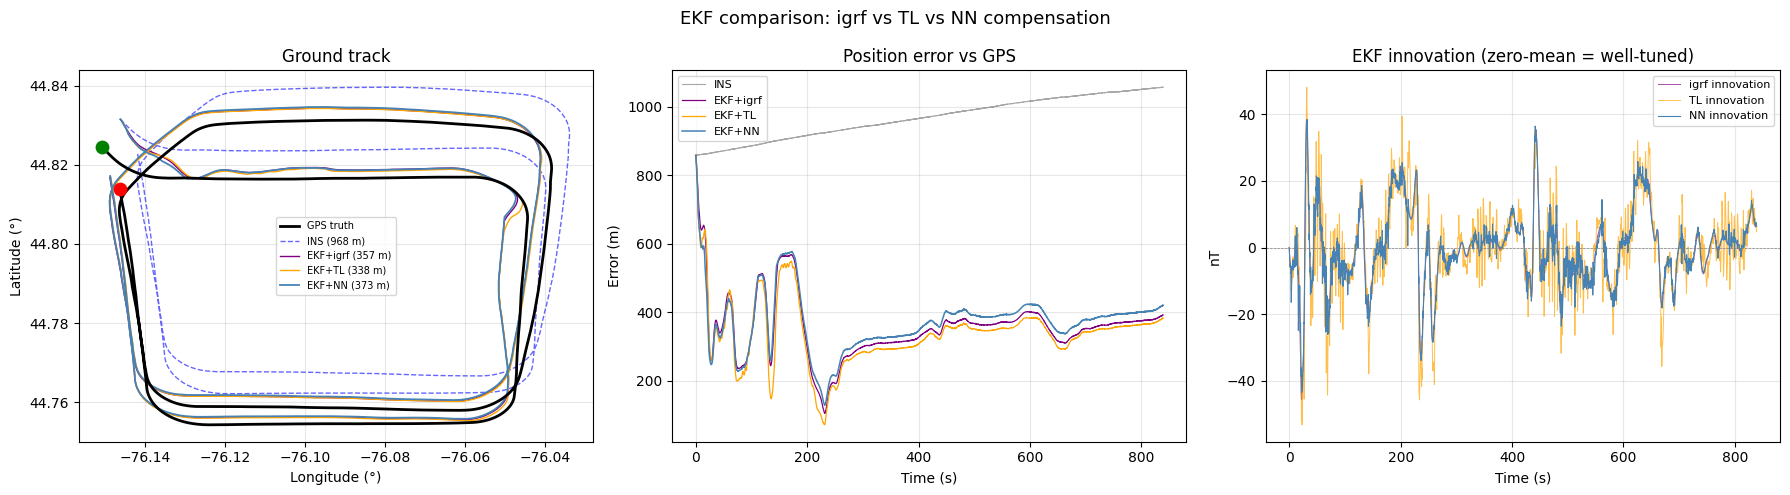

In [ ]:
t_plot = df_test['tt'].values - df_test['tt'].values[0]
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EKF comparison: igrf vs TL vs NN compensation', fontsize=13)
 
ax = axes[0]
ax.plot(lon_gt,            lat_gt,            'k-',  lw=2,   label='GPS truth', zorder=4)
ax.plot(ins_lon_deg,       ins_lat_deg,       'b--', lw=1,   alpha=0.6,
        label=f'INS ({ins_err.mean():.0f} m)')
ax.plot(ekf_igrf['lon'],   ekf_igrf['lat'],   color='purple', lw=1,
        label=f'EKF+igrf ({err_igrf.mean():.0f} m)')
ax.plot(ekf_tl['lon'],     ekf_tl['lat'],     color='orange', lw=1,
        label=f'EKF+TL ({err_tl.mean():.0f} m)')
ax.plot(ekf_nn['lon'],     ekf_nn['lat'],     color='steelblue', lw=1.3,
        label=f'EKF+NN ({err_nn.mean():.0f} m)')
ax.scatter(lon_gt[0],  lat_gt[0],  c='green', s=80, zorder=5)
ax.scatter(lon_gt[-1], lat_gt[-1], c='red',   s=80, zorder=5)
ax.set_xlabel('Longitude (°)'); ax.set_ylabel('Latitude (°)')
ax.set_title('Ground track'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
 
ax = axes[1]
ax.plot(t_plot, ins_err,  lw=0.8, color='gray',      alpha=0.7, label='INS')
ax.plot(t_plot, err_igrf, lw=0.9, color='purple',               label='EKF+igrf')
ax.plot(t_plot, err_tl,   lw=0.9, color='orange',               label='EKF+TL')
ax.plot(t_plot, err_nn,   lw=1.1, color='steelblue',            label='EKF+NN')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Error (m)')
ax.set_title('Position error vs GPS'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
 
ax = axes[2]
ax.plot(t_plot, ekf_igrf['innov'], lw=0.7, color='purple',    alpha=0.7, label='igrf innovation')
ax.plot(t_plot, ekf_tl['innov'],   lw=0.7, color='orange',    alpha=0.7, label='TL innovation')
ax.plot(t_plot, ekf_nn['innov'],   lw=0.8, color='steelblue',            label='NN innovation')
ax.axhline(0, color='gray', lw=0.5, linestyle='--')
ax.set_xlabel('Time (s)'); ax.set_ylabel('nT')
ax.set_title('EKF innovation (zero-mean = well-tuned)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('ekf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()